<a href="https://colab.research.google.com/github/dinujakr/Final-year-project-IEKF-for-rigid-body-tracking/blob/main/Right_invariant_Intrinsic_EKF_on_Euroc_MAV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/FYP')  # adjust to where you put so3_ekf_lib.py


The Intrinsic EKF for estimating R

Mean dt: 0.005000 s  (200.0 Hz)
Initial R0 from GT quaternion at t=1.215 s
  q0 = [ 0.604566  0.026558 -0.795388  0.03395 ]
First normalised accel (avg body): [ 0.96048424  0.01651549 -0.27784394]
Recovered g_inertial direction:    [0.00831856 0.03923129 0.99919553]
Using e_gravity = [0. 0. 1.]

Noise parameters:
  Sigma_q diagonal (gyro): 5.78e-05
  Sigma_q diagonal (bias): 1.81e-11
  Sigma_m diagonal:        2.50e-03

Running SO(3) error-state EKF with bias estimation...
  T = 23369 steps, dt = 0.0050 s
  Inertial directions: [[0. 0. 1.]]
  Done.

  SO(3) Error-State EKF -- RMSE Report [V2_03_difficult]
  Roll  RMSE : 5.371 degrees
  Pitch RMSE : 1.362 degrees
  Yaw   RMSE : 116.074 degrees


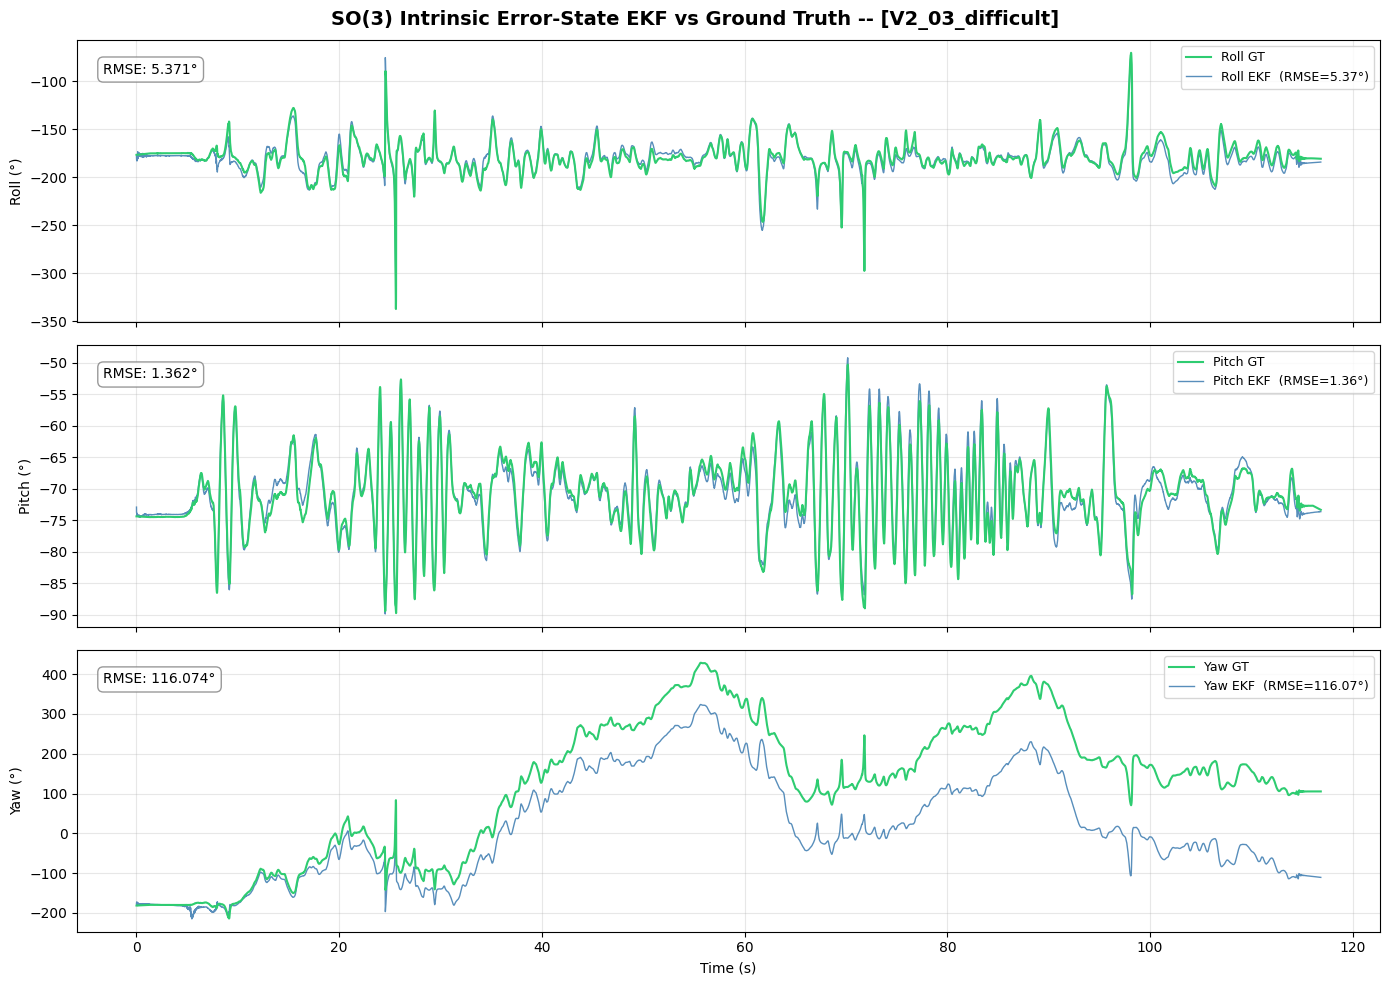

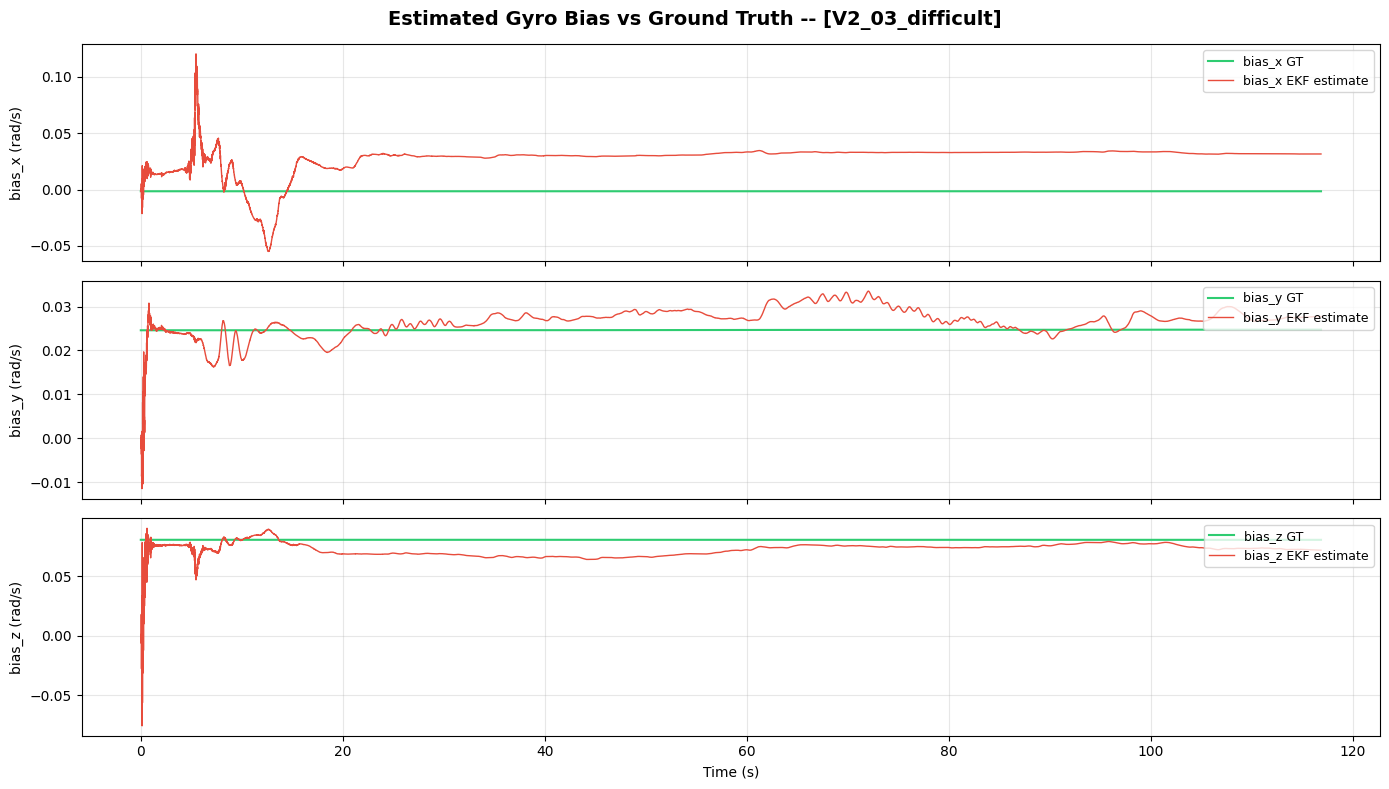

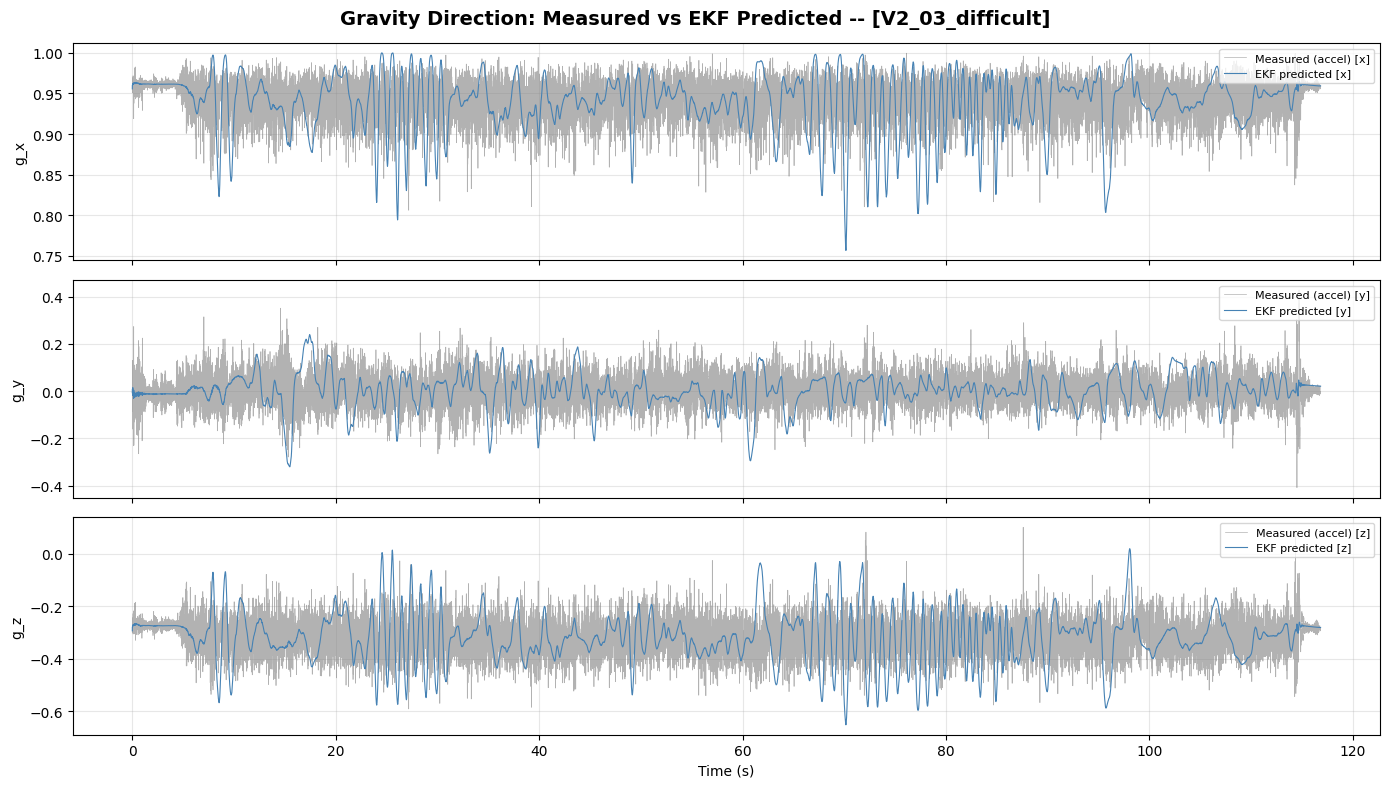


Done. Figures displayed.


In [3]:
"""
run_so3_ekf.py
==============
Intrinsic SO(3) Error-State EKF with Gyro Bias Estimation
on the EuRoC MAV dataset.

Uses SO3IMUSensorFusionBiasEKF from so3_ekf_lib.py.

Measurement model:
    The accelerometer measures the gravity direction in the body frame.
    With inertial gravity direction e_g = [0, 0, -1], the measurement is:
        y_k = R_k^T e_g + noise
    We normalise the accelerometer reading to get a unit-vector measurement.

Error state:
    eta = [eta_R; eta_b] in R^6
    - eta_R: attitude error (Lie algebra so(3))
    - eta_b: gyro bias error

Note:
    With only gravity (1 direction), yaw is unobservable.
    Roll and pitch are corrected; yaw drifts unless a magnetometer is added.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.spatial.transform import Rotation

from so3_ekf_lib import LinearKF, SO3IMUSensorFusionBiasEKF

# ============================================================
# CONFIG — change dataset path here
# ============================================================
DATASET_NAME = "V2_03_difficult"
DATASET = f"/content/drive/MyDrive/FYP/{DATASET_NAME}"

# ============================================================
# LOAD DATA
# ============================================================
imu_path = DATASET + "/imu0/data.csv"
gt_path  = DATASET + "/state_groundtruth_estimate0/data.csv"

imu = pd.read_csv(imu_path)
gt  = pd.read_csv(gt_path)

# Common time reference
t0 = min(imu.iloc[0, 0], gt.iloc[0, 0])

# IMU data
t_imu = (imu.iloc[:, 0].values - t0) * 1e-9   # seconds
gyro  = imu.iloc[:, 1:4].values                # (T, 3)  rad/s
acc   = imu.iloc[:, 4:7].values                # (T, 3)  m/s^2

# Ground truth
t_gt = (gt.iloc[:, 0].values - t0) * 1e-9
q_gt = gt[[' q_RS_w []', ' q_RS_x []',
           ' q_RS_y []', ' q_RS_z []']].values  # (w, x, y, z)

# GT gyro bias (for reference / optional initialisation)
b_gt = gt[[' b_w_RS_S_x [rad s^-1]',
           ' b_w_RS_S_y [rad s^-1]',
           ' b_w_RS_S_z [rad s^-1]']].values

# ============================================================
# UTILITY FUNCTIONS
# ============================================================
def quat_to_rotmat(q_wxyz):
    """Hamilton quaternion (w,x,y,z) → 3x3 rotation matrix."""
    w, x, y, z = q_wxyz
    # scipy uses (x,y,z,w) convention
    return Rotation.from_quat([x, y, z, w]).as_matrix()


def rotmat_to_euler(R):
    """Rotation matrix → intrinsic ZYX Euler angles (roll, pitch, yaw)."""
    # scipy 'ZYX' extrinsic = 'xyz' intrinsic
    r = Rotation.from_matrix(R)
    # Returns [roll, pitch, yaw] in radians
    return r.as_euler('xyz', degrees=False)


def quat_to_euler(q_wxyz):
    """Hamilton quaternion (w,x,y,z) → (roll, pitch, yaw)."""
    w, x, y, z = q_wxyz
    r = Rotation.from_quat([x, y, z, w])
    return r.as_euler('xyz', degrees=False)


def unwrap_angle(a):
    """Manual unwrap to avoid ±π jumps."""
    a = a.copy()
    for i in range(1, len(a)):
        while a[i] - a[i - 1] > np.pi:
            a[i] -= 2 * np.pi
        while a[i] - a[i - 1] < -np.pi:
            a[i] += 2 * np.pi
    return a


def wrap_innovation(d):
    """Wrap angle difference to [-π, π]."""
    return (d + np.pi) % (2 * np.pi) - np.pi

# ============================================================
# PREPARE MEASUREMENTS
# ============================================================
# Number of IMU samples to process (T-1 steps, using pairs for dt)
T = len(t_imu) - 1

# Gyroscope: use samples 0..T-1
Omegas = gyro[:T]    # (T, 3)

# Accelerometer → normalised gravity direction measurement
# Measurement model: y_k = R_k^T * e_gravity + noise
# e_gravity = [0, 0, -1] in inertial frame
# y_k = normalised(acc_k) ≈ R_k^T * [0, 0, -1]   (when stationary)
acc_norms = np.linalg.norm(acc[:T], axis=1, keepdims=True)
acc_norms = np.clip(acc_norms, 1e-6, None)  # avoid division by zero
Ys = acc[:T] / acc_norms   # (T, 3)  normalised accelerometer

# Time array for results
time_ekf = t_imu[:T]

# Compute dt (should be ~0.005 s for 200 Hz)
dt_mean = np.mean(np.diff(t_imu[:T + 1]))
print(f"Mean dt: {dt_mean:.6f} s  ({1 / dt_mean:.1f} Hz)")

# ============================================================
# INITIALISE THE EKF
# ============================================================
# Inertial direction: gravity points down → e = [0, 0, -1]
# (The accelerometer, when at rest, measures -g in body frame,
#  i.e. acc ≈ R^T * [0, 0, +9.81].  After normalisation:
#  acc_norm ≈ R^T * [0, 0, +1].  But we want to match
#  the sign convention in the EKF which uses R^T * e.
#  So if acc_norm ≈ R^T * [0,0,+1], then e = [0, 0, +1].)
#
# Let's verify: for EuRoC, at rest the accelerometer reads
# approximately [0, 0, +9.81] when the sensor is level.
# After normalisation: [0, 0, +1] = R^T * e_inertial.
# If R = I (level), then e_inertial = [0, 0, +1].

# Initial attitude from first ground-truth quaternion
# Find the GT sample closest to the first IMU time
idx0 = np.argmin(np.abs(t_gt - time_ekf[0]))
R0 = quat_to_rotmat(q_gt[idx0])
print(f"Initial R0 from GT quaternion at t={t_gt[idx0]:.3f} s")
print(f"  q0 = {q_gt[idx0]}")

# Determine the inertial gravity direction.
# The accelerometer at rest measures a = R^T * g_inertial.
# Using R0 from GT and the first accel readings, we can recover g_inertial:
#   g_inertial = R0 * normalise(acc_first)
acc_first = acc[:10].mean(axis=0)
acc_first_norm = acc_first / np.linalg.norm(acc_first)
g_inertial = R0 @ acc_first_norm
print(f"First normalised accel (avg body): {acc_first_norm}")
print(f"Recovered g_inertial direction:    {g_inertial}")

# Round to nearest axis for a clean inertial reference direction
# (EuRoC gravity is along one of the principal axes)
axis_idx = np.argmax(np.abs(g_inertial))
e_gravity_vec = np.zeros(3)
e_gravity_vec[axis_idx] = np.sign(g_inertial[axis_idx])
e_gravity = e_gravity_vec.reshape(1, 3)   # (1, 3)
print(f"Using e_gravity = {e_gravity_vec}")

# Initial gyro bias estimate (start from zero — let the filter estimate it)
b0 = np.zeros(3)

# Initial error covariance P0 (6x6)
# [eta_R covariance (3x3) | 0           ]
# [0                      | eta_b (3x3) ]
P0 = np.block([
    [0.01 * np.eye(3),   np.zeros((3, 3))],
    [np.zeros((3, 3)),   0.01 * np.eye(3)],
])

# ============================================================
# NOISE PARAMETERS (EuRoC ADIS16448 IMU specs)
# ============================================================
# Gyro noise density: σ_g ≈ 1.7e-4 rad/s/√Hz
# At 200 Hz: σ²_gyro_per_step ≈ (1.7e-4)² * 200 ≈ 5.8e-6 rad²
sigma_gyro = 1.7e-4   # rad/s/√Hz
sigma2_gyro = (sigma_gyro ** 2) / dt_mean  # discrete-time variance

# Gyro bias random walk: σ_bw ≈ 1.9e-5 rad/s²/√Hz
sigma_bias_walk = 1.9e-5
sigma2_bias = (sigma_bias_walk ** 2) * dt_mean

# Inflate slightly for robustness
gyro_noise_factor = 10.0
bias_noise_factor = 10.0

Sigma_q = np.block([
    [sigma2_gyro * gyro_noise_factor * np.eye(3), np.zeros((3, 3))],
    [np.zeros((3, 3)), sigma2_bias * bias_noise_factor * np.eye(3)],
])

# Measurement noise: accelerometer noise on normalised direction
# Accel noise density: ~2e-3 m/s²/√Hz
# On normalised vector (divided by ~9.81), noise ≈ 2e-4 /√Hz
# During motion, linear acceleration corrupts → inflate significantly
sigma_accel_dir = 0.05   # per-component std on unit sphere measurement
Sigma_m = (sigma_accel_dir ** 2) * np.eye(3)

print(f"\nNoise parameters:")
print(f"  Sigma_q diagonal (gyro): {sigma2_gyro * gyro_noise_factor:.2e}")
print(f"  Sigma_q diagonal (bias): {sigma2_bias * bias_noise_factor:.2e}")
print(f"  Sigma_m diagonal:        {sigma_accel_dir**2:.2e}")

# ============================================================
# BUILD AND RUN THE EKF
# ============================================================
kf = LinearKF(use_joseph=True, symmetrize=True)
ekf = SO3IMUSensorFusionBiasEKF(
    kf=kf,
    inertial_directions=e_gravity,
    dt=dt_mean,
)

print(f"\nRunning SO(3) error-state EKF with bias estimation...")
print(f"  T = {T} steps, dt = {dt_mean:.4f} s")
print(f"  Inertial directions: {e_gravity}")

results = ekf.run_filter(
    R0_plus=R0,
    P0=P0,
    Omegas=Omegas,
    Ys=Ys,
    Sigma_q=Sigma_q,
    Sigma_m=Sigma_m,
    b0_plus=b0,
    store_corrected_yhat=True,
)

print("  Done.")

# ============================================================
# EXTRACT EULER ANGLES FROM R_plus
# ============================================================
R_plus_arr = results["R_plus"]     # (T, 3, 3)
b_plus_arr = results["b_plus"]     # (T, 3)

euler_ekf = np.array([rotmat_to_euler(R_plus_arr[k]) for k in range(T)])

# Unwrap for continuous plotting
euler_ekf[:, 0] = unwrap_angle(euler_ekf[:, 0])
euler_ekf[:, 1] = unwrap_angle(euler_ekf[:, 1])
euler_ekf[:, 2] = unwrap_angle(euler_ekf[:, 2])

# ============================================================
# GROUND TRUTH EULER ANGLES
# ============================================================
euler_gt = np.array([quat_to_euler(q) for q in q_gt])
euler_gt[:, 0] = unwrap_angle(euler_gt[:, 0])
euler_gt[:, 1] = unwrap_angle(euler_gt[:, 1])
euler_gt[:, 2] = unwrap_angle(euler_gt[:, 2])

# ============================================================
# COMPUTE RMSE
# ============================================================
def compute_rmse(est, gt_col, t_est, t_gt_col):
    f = interp1d(t_gt_col, gt_col, bounds_error=False, fill_value="extrapolate")
    gt_interp = f(t_est)
    diff = wrap_innovation(est - gt_interp)
    return np.sqrt(np.mean(diff ** 2))


rmse_roll  = np.degrees(compute_rmse(euler_ekf[:, 0], euler_gt[:, 0], time_ekf, t_gt))
rmse_pitch = np.degrees(compute_rmse(euler_ekf[:, 1], euler_gt[:, 1], time_ekf, t_gt))
rmse_yaw   = np.degrees(compute_rmse(euler_ekf[:, 2], euler_gt[:, 2], time_ekf, t_gt))

print(f"\n{'=' * 50}")
print(f"  SO(3) Error-State EKF -- RMSE Report [{DATASET_NAME}]")
print(f"{'=' * 50}")
print(f"  Roll  RMSE : {rmse_roll:.3f} degrees")
print(f"  Pitch RMSE : {rmse_pitch:.3f} degrees")
print(f"  Yaw   RMSE : {rmse_yaw:.3f} degrees")
print(f"{'=' * 50}")

# ============================================================
# GROUND TRUTH GYRO BIAS (for comparison)
# ============================================================
# Interpolate GT bias to EKF timestamps
b_gt_interp = np.zeros((T, 3))
for j in range(3):
    f_b = interp1d(t_gt, b_gt[:, j], bounds_error=False, fill_value="extrapolate")
    b_gt_interp[:, j] = f_b(time_ekf)

# ============================================================
# PLOTS
# ============================================================
# Interpolate GT Euler to EKF timestamps for overlay
gt_at_ekf = np.zeros((T, 3))
for j in range(3):
    f = interp1d(t_gt, euler_gt[:, j], bounds_error=False, fill_value="extrapolate")
    gt_at_ekf[:, j] = f(time_ekf)

angle_labels = ['Roll', 'Pitch', 'Yaw']
rmse_vals = [rmse_roll, rmse_pitch, rmse_yaw]

# ---- Figure 1: Roll / Pitch / Yaw vs Ground Truth ----
fig1, axes1 = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig1.suptitle(
    f"SO(3) Intrinsic Error-State EKF vs Ground Truth -- [{DATASET_NAME}]",
    fontsize=14, fontweight='bold')

for i, (ax, lbl) in enumerate(zip(axes1, angle_labels)):
    ax.plot(time_ekf, np.degrees(gt_at_ekf[:, i]),
            color='#2ecc71', linewidth=1.5, label=f'{lbl} GT', zorder=3)
    ax.plot(time_ekf, np.degrees(euler_ekf[:, i]),
            color='steelblue', linewidth=1.0, alpha=0.9,
            label=f'{lbl} EKF  (RMSE={rmse_vals[i]:.2f}°)')

    ax.set_ylabel(f'{lbl} (°)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

    # RMSE annotation
    ax.text(0.02, 0.92, f"RMSE: {rmse_vals[i]:.3f}°",
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='gray', alpha=0.8))

axes1[-1].set_xlabel('Time (s)')
plt.tight_layout()

# ---- Figure 2: Estimated Gyro Bias vs GT Bias ----
bias_labels = ['bias_x', 'bias_y', 'bias_z']
fig2, axes2 = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig2.suptitle(
    f"Estimated Gyro Bias vs Ground Truth -- [{DATASET_NAME}]",
    fontsize=14, fontweight='bold')

for j in range(3):
    axes2[j].plot(time_ekf, b_gt_interp[:, j],
                  color='#2ecc71', linewidth=1.5,
                  label=f'{bias_labels[j]} GT')
    axes2[j].plot(time_ekf, b_plus_arr[:, j],
                  color='#e74c3c', linewidth=1.0,
                  label=f'{bias_labels[j]} EKF estimate')
    axes2[j].set_ylabel(f'{bias_labels[j]} (rad/s)')
    axes2[j].legend(loc='upper right', fontsize=9)
    axes2[j].grid(True, alpha=0.3)

axes2[-1].set_xlabel('Time (s)')
plt.tight_layout()

# ---- Figure 3: Direction measurement fit ----
yhat_arr = results["yhat"]   # (T, 3)
comp_labels = ['x', 'y', 'z']

fig3, axes3 = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig3.suptitle(
    f"Gravity Direction: Measured vs EKF Predicted -- [{DATASET_NAME}]",
    fontsize=14, fontweight='bold')

for j in range(3):
    axes3[j].plot(time_ekf, Ys[:, j],
                  color='gray', linewidth=0.5, alpha=0.6,
                  label=f'Measured (accel) [{comp_labels[j]}]')
    axes3[j].plot(time_ekf, yhat_arr[:, j],
                  color='steelblue', linewidth=0.8,
                  label=f'EKF predicted [{comp_labels[j]}]')
    axes3[j].set_ylabel(f'g_{comp_labels[j]}')
    axes3[j].legend(loc='upper right', fontsize=8)
    axes3[j].grid(True, alpha=0.3)

axes3[-1].set_xlabel('Time (s)')
plt.tight_layout()

plt.show()

print("\nDone. Figures displayed.")
